In [1]:
import copy, random, csv, re
import numpy as np
import torch, torch.nn as nn
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms
import matplotlib.pyplot as plt


SEED = 42
def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.benchmark = False
    torch.backends.cudnn.deterministic = True
 
device = "cuda" if torch.cuda.is_available() else "cpu"
set_seed(SEED)

In [2]:
tfm = transforms.ToTensor()
full_train = datasets.FashionMNIST("./data", train=True,  download=True, transform=tfm)
test_ds    = datasets.FashionMNIST("./data", train=False, download=True, transform=tfm)
n_unused = len(full_train) - 6000 - 1000
train_ds, val_ds, _ = random_split(
    full_train, [6000, 1000, n_unused],
    generator=torch.Generator().manual_seed(SEED)
)

def make_loader(ds, shuffle, seed=SEED):
    g = torch.Generator().manual_seed(seed)
    return DataLoader(ds, batch_size=128, shuffle=shuffle, generator=g if shuffle else None)

val_loader  = make_loader(val_ds,  False)
test_loader = make_loader(test_ds, False)
print(len(train_ds), len(val_ds), len(test_ds))

print(torch.Generator().manual_seed(SEED))

6000 1000 10000


In [ ]:
def build_model():
    return nn.Sequential(
        nn.Flatten(),
        nn.Linear(784, 128),
        nn.ReLU(),
        nn.Linear(128, 10),
    )

# One set of initial weights, shared by both runs
set_seed(SEED)
init_state = copy.deepcopy(build_model().state_dict())

hard_loss = nn.CrossEntropyLoss(label_smoothing=0.0, reduction="sum")
soft_loss = nn.CrossEntropyLoss(label_smoothing=0.1)

@torch.no_grad()
def evaluate(model, loader):
    """Returns hard-loss CE (mean per sample), accuracy, and all confidences."""
    model.eval()
    tot_loss, correct, n, confs = 0.0, 0, 0, []
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        logits = model(x)
        tot_loss += hard_loss(logits, y).item()
        correct  += (logits.argmax(-1) == y).sum().item()
        n += y.size(0)
        confs.append(torch.softmax(logits, dim=-1).max(dim=-1).values.cpu())
    return tot_loss / n, correct / n, torch.cat(confs).numpy()

def train_model(train_criterion, epochs=10):
    model = build_model().to(device)
    model.load_state_dict(init_state)
    opt = torch.optim.Adam(model.parameters(), lr=0.001)
    train_loader = make_loader(train_ds, True, SEED)   # same shuffle order for both runs

    best_val, best_epoch, best_state = float("inf"), None, None
    for ep in range(1, epochs + 1):
        model.train()
        for x, y in train_loader:
            x, y = x.to(device), y.to(device)
            opt.zero_grad()
            train_criterion(model(x), y).backward()
            opt.step()

        val_loss, val_acc, _ = evaluate(model, val_loader)   # validation always uses hard CE
        print(f"epoch {ep:2d} | val CE {val_loss:.4f} | val acc {val_acc:.4f}")
        if val_loss < best_val:          # strict '<' keeps the earlier epoch on ties
            best_val, best_epoch = val_loss, ep
            best_state = copy.deepcopy(model.state_dict())

    model.load_state_dict(best_state)    # restore best checkpoint before testing
    return model, best_epoch

In [4]:
results, test_confs = {}, {}
for name, crit in [("Hard (ls=0.0)", hard_loss), ("Soft (ls=0.1)", soft_loss)]:
    print(f"\n=== {name} ===")
    model, best_ep = train_model(crit, epochs=10)
    _, test_acc, confs = evaluate(model, test_loader)
    results[name] = dict(epoch=best_ep, acc=test_acc, conf=confs.mean())
    test_confs[name] = confs

print("\n{:<16}{:>16}{:>15}{:>20}".format("Model", "Selected epoch", "Test acc", "Mean test conf"))
for k, v in results.items():
    print("{:<16}{:>16d}{:>15.4f}{:>20.4f}".format(k, v["epoch"], v["acc"], v["conf"]))


=== Hard (ls=0.0) ===
epoch  1 | val CE 0.7551 | val acc 0.7310
epoch  2 | val CE 0.6329 | val acc 0.7820
epoch  3 | val CE 0.5538 | val acc 0.8020
epoch  4 | val CE 0.5343 | val acc 0.8160
epoch  5 | val CE 0.4969 | val acc 0.8350
epoch  6 | val CE 0.5003 | val acc 0.8240
epoch  7 | val CE 0.4784 | val acc 0.8370
epoch  8 | val CE 0.4606 | val acc 0.8470
epoch  9 | val CE 0.4641 | val acc 0.8300
epoch 10 | val CE 0.4764 | val acc 0.8330

=== Soft (ls=0.1) ===
epoch  1 | val CE 0.8085 | val acc 0.7390
epoch  2 | val CE 0.7086 | val acc 0.7870
epoch  3 | val CE 0.6464 | val acc 0.8060
epoch  4 | val CE 0.6200 | val acc 0.8170
epoch  5 | val CE 0.5806 | val acc 0.8360
epoch  6 | val CE 0.5776 | val acc 0.8320
epoch  7 | val CE 0.5686 | val acc 0.8410
epoch  8 | val CE 0.5521 | val acc 0.8510
epoch  9 | val CE 0.5565 | val acc 0.8370
epoch 10 | val CE 0.5553 | val acc 0.8330

Model             Selected epoch       Test acc      Mean test conf
Hard (ls=0.0)                  8         0.82

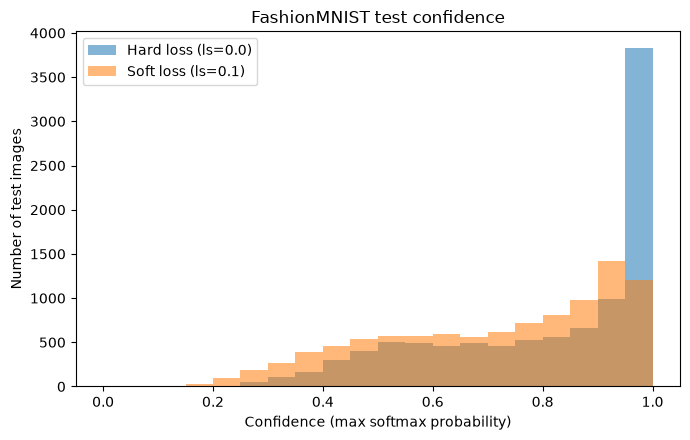

In [5]:
bins = np.linspace(0, 1, 21)   # 20 equal-width bins from 0 to 1
plt.figure(figsize=(7, 4.5))
plt.hist(test_confs["Hard (ls=0.0)"], bins=bins, alpha=0.55, label="Hard loss (ls=0.0)")
plt.hist(test_confs["Soft (ls=0.1)"], bins=bins, alpha=0.55, label="Soft loss (ls=0.1)")
plt.xlabel("Confidence (max softmax probability)")
plt.ylabel("Number of test images")
plt.title("FashionMNIST test confidence")
plt.legend()
plt.tight_layout()
plt.show()

Label smoothing left accuracy essentially unchanged (82.31% hard vs 82.48% soft, both selected at epoch 8, a 0.17-point gap that is within noise for one seed) but clearly lowered confidence: mean test confidence fell from 0.807 to 0.7145. The histogram shows why: the hard-loss model piles about 3,800 test images into the top bin (0.95 to 1.0), while the soft-loss model has only about 1,200 there and shifts mass into the 0.8 to 0.95 range. With hard targets, cross-entropy keeps falling as the true-class probability approaches 1, so the gradient always pushes the logit gap larger. With a 0.91/0.01 target, the loss is minimized when the model outputs about 0.91 for the true class, and pushing beyond that increases the loss because the 0.01 on the other classes is penalized. That puts a ceiling on useful confidence, so the model has no incentive to produce the extreme logits that dominate the hard-loss histogram

In [6]:
with open("names.csv", encoding="utf-8-sig", newline="") as f:
    names = sorted({
        re.sub(r"[^a-z]", "", row["Name"].lower())
        for row in csv.DictReader(f)
    } - {""})
assert len(names) == 6478


g = torch.Generator().manual_seed(42)
order = torch.randperm(len(names), generator=g).tolist()
train_names = [names[i] for i in order[:5182]]
val_names   = [names[i] for i in order[5182:5829]]
test_names  = [names[i] for i in order[5829:]]
print(len(train_names), len(val_names), len(test_names))

stoi = {ch: i for i, ch in enumerate("-abcdefghijklmnopqrstuvwxyz")}
itos = {i: ch for ch, i in stoi.items()}   # 0 -> '-' (start/end token)




5182 647 649


In [12]:
def build_examples(name_list):
    X, Y = [], []
    for name in name_list:
        ctx = [0, 0, 0]                    # reset context for every name
        for ch in name + "-":              # final end token is a target
            ix = stoi[ch]
            X.append(ctx)
            Y.append(ix)
            ctx = ctx[1:] + [ix]
    return torch.tensor(X), torch.tensor(Y)

Xtr, Ytr = build_examples(train_names)
Xva, Yva = build_examples(val_names)
Xte, Yte = build_examples(test_names)


# print(Xtr.shape, Xva.shape, Xte.shape)

In [13]:
set_seed(43)

embedding = nn.Embedding(27, 2)

network = nn.Sequential(
    nn.Linear(6, 32),
    nn.ReLU(),
    nn.Linear(32, 27),
)

def forward(context_ids):
    return network(embedding(context_ids).reshape(-1, 6))

criterion = nn.CrossEntropyLoss()   # natural log -> nats per token

@torch.no_grad()
def evaluate(X, Y):
    """Exact mean loss over all predicted tokens (full set in one pass)."""
    embedding.eval(); network.eval()
    return criterion(forward(X), Y).item()

epoch  1 | train 2.8048 | val 2.8023
epoch  2 | train 2.7058 | val 2.7061
epoch  3 | train 2.6395 | val 2.6375
epoch  4 | train 2.5632 | val 2.5602
epoch  5 | train 2.4858 | val 2.4798
epoch  6 | train 2.4351 | val 2.4277
epoch  7 | train 2.4074 | val 2.3999
epoch  8 | train 2.3914 | val 2.3838
epoch  9 | train 2.3807 | val 2.3715
epoch 10 | train 2.3718 | val 2.3641
epoch 11 | train 2.3650 | val 2.3572
epoch 12 | train 2.3587 | val 2.3515
epoch 13 | train 2.3525 | val 2.3460
epoch 14 | train 2.3474 | val 2.3401
epoch 15 | train 2.3436 | val 2.3360
epoch 16 | train 2.3396 | val 2.3327
epoch 17 | train 2.3357 | val 2.3277
epoch 18 | train 2.3323 | val 2.3260
epoch 19 | train 2.3295 | val 2.3226
epoch 20 | train 2.3272 | val 2.3222

Selected epoch: 20
Test loss: 2.3552 nats/token


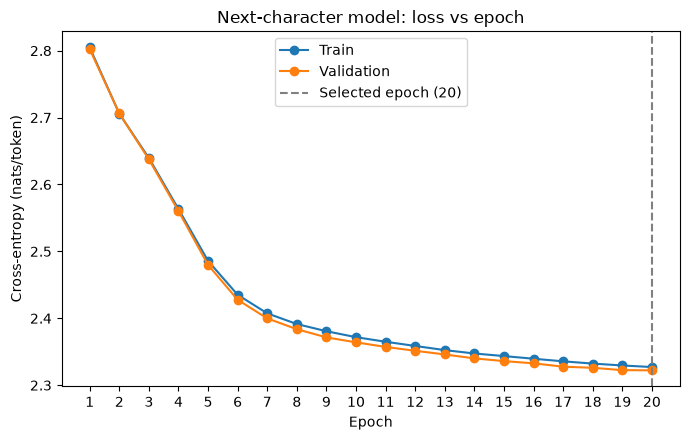

In [9]:
EPOCHS, BATCH = 20, 256

# both embedding and network parameters go to the optimizer
params = list(embedding.parameters()) + list(network.parameters())
opt = torch.optim.Adam(params, lr=0.001)
shuffle_g = torch.Generator().manual_seed(42)
train_losses, val_losses = [], []
best_val, best_epoch, best_emb, best_net = float("inf"), None, None, None

for ep in range(1, EPOCHS + 1):
    embedding.train(); network.train()
    perm = torch.randperm(len(Xtr), generator=shuffle_g)
    for i in range(0, len(Xtr), BATCH):
        idx = perm[i:i + BATCH]
        opt.zero_grad()
        criterion(forward(Xtr[idx]), Ytr[idx]).backward()
        opt.step()

    # evaluate both sets at the end of the epoch
    tr, va = evaluate(Xtr, Ytr), evaluate(Xva, Yva)
    train_losses.append(tr); val_losses.append(va)
    print(f"epoch {ep:2d} | train {tr:.4f} | val {va:.4f}")

    if va < best_val:                    # strict '<' keeps earlier epoch on ties
        best_val, best_epoch = va, ep
        best_emb = copy.deepcopy(embedding.state_dict())
        best_net = copy.deepcopy(network.state_dict())

# restore best weights (embedding AND network) before testing
embedding.load_state_dict(best_emb)
network.load_state_dict(best_net)

test_loss = evaluate(Xte, Yte)
print(f"\nSelected epoch: {best_epoch}")
print(f"Test loss: {test_loss:.4f} nats/token")

plt.figure(figsize=(7, 4.5))
epochs = range(1, EPOCHS + 1)
plt.plot(epochs, train_losses, marker="o", label="Train")
plt.plot(epochs, val_losses, marker="o", label="Validation")
plt.axvline(best_epoch, color="gray", linestyle="--", label=f"Selected epoch ({best_epoch})")
plt.xlabel("Epoch"); plt.ylabel("Cross-entropy (nats/token)")
plt.title("Next-character model: loss vs epoch")
plt.xticks(list(epochs)); plt.legend(); plt.tight_layout(); plt.show()

In [10]:
MAX_LETTERS = 20

@torch.no_grad()
def generate(mode, temperature=1.0):
    embedding.eval(); network.eval()
    ctx, out = [0, 0, 0], []
    for _ in range(MAX_LETTERS):
        logits = forward(torch.tensor([ctx]))
        if mode == "greedy":
            next_id = logits.argmax(dim=-1).item()
        else:
            probabilities = torch.softmax(logits / temperature, dim=-1)
            next_id = torch.multinomial(probabilities, num_samples=1).item()
        if next_id == 0:                 # end token
            hit_limit = False
            break
        out.append(itos[next_id])
        ctx = ctx[1:] + [next_id]        # slide the context
    else:
        hit_limit = True                 # loop finished without an end token
    return "".join(out), hit_limit

def show(name, hit_limit):
    if name == "":
        return "<empty>"
    return name + ("  [hit 20-letter limit]" if hit_limit else "")

print("Greedy:")
n, h = generate("greedy")
print("  ", show(n, h))

for T in [0.5, 1, 2]:
    torch.manual_seed(43)                # reset before each temperature group
    print(f"\nTemperature {T}:")
    for _ in range(5):
        n, h = generate("sample", T)
        print("  ", show(n, h))

Greedy:
   san

Temperature 0.5:
   ran
   rai
   bac
   cam
   ram

Temperature 1:
   rer
   rainhac
   cumaramed
   shink
   banin

Temperature 2:
   ref
   roinbaclcvmpracedjul  [hit 20-letter limit]
   rekbbaiinuitah
   vosh
   paf


Greedy generation has no randomness: the same start tokens give the same logits, argmax picks the same character, and every later step follows, so it always gives "san". At temperature 0.5, the sharpened distribution gave short, clean names (ran, rai, bac, cam, ram) that stayed close to the model's most likely letters. At temperature 1 the samples were more varied and longer (rainhac, cumaramed), and at temperature 2 the flattened distribution gave rambling strings (rekbbaiinuitah), including one that hit the 20-letter limit. All samples came from the same trained model, so only the temperature changed how its probabilities were sampled.